# 结肠组织数据批次效应去除
使用scVI

# 文件说明
- **文件名**: tissue_dataset_scvi.h5ad
- **存放位置**: 坚果云  `UC/scRNA-seq_data/05_scvi_integrated/`  
- **生成日期**: 2025-11-10  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.3_data_merge/2_batch_correction.ipynb  
- **内容说明**: 结肠组织数据批次效应去除，scVI

## 环境与路径

In [1]:
# 基础依赖
import os, random, numpy as np, pandas as pd
import scanpy as sc
import omicverse as ov
ov.plot_set()
ov.settings.cpu_gpu_mixed_init()
import scvi

# I/O
MERGED_PATH = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/04_dataset_merge/tissue_dataset_merged_log_normalized.h5ad"
SAVE_DIR    = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/05_scvi_integrated"
os.makedirs(SAVE_DIR, exist_ok=True)
OUT_PATH    = os.path.join(SAVE_DIR, "tissue_dataset_scvi.h5ad")

# 全局参数
RANDOM_SEED = 0
HVG_N_TOP   = 3000
N_NEI       = 15
SCVI_LATENT = 30
MAX_EPOCHS  = 200
RES         = 0.2

# 固定随机性
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
scvi.settings.seed = RANDOM_SEED
sc.settings.set_figure_params(dpi=110, facecolor="white")


/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


Seed set to 0


## 1.数据读取与检查

In [2]:
adata = sc.read_h5ad(MERGED_PATH)
print(adata)

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE'
    var: 'mt'
    uns: 'log1p'
    layers: 'counts'


374507个细胞，11743个基因

In [4]:
adata.layers.keys()

KeysView(Layers with keys: counts)

In [5]:
adata.raw is not None

True

In [6]:
# 关键元信息
for c in ["GSE", "GSM"]:
    assert c in adata.obs.columns, f"缺少 obs['{c}']"
    adata.obs[c] = adata.obs[c].astype("category")

In [7]:
adata.obs.head()

,n_genes,GSM,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet,group,GSE
GSM8980878_UC68_CELL6_N4,790,GSM8980878,1128.0,0.079787,790,0.700355,True,True,True,0.024741,False,UC,GSE296969
GSM8980878_UC68_CELL10_N2,1807,GSM8980878,3051.0,0.077352,1807,0.592265,True,True,True,0.025539,False,UC,GSE296969
GSM8980878_UC68_CELL14_N2,3154,GSM8980878,6273.0,0.039694,3154,0.502790,True,True,True,0.011227,False,UC,GSE296969
GSM8980878_UC68_CELL20_N5,2054,GSM8980878,3109.0,0.019620,2054,0.660663,True,True,True,0.068769,False,UC,GSE296969
GSM8980878_UC68_CELL21_N3,4763,GSM8980878,11899.0,0.027986,4763,0.400286,True,True,True,0.046935,False,UC,GSE296969


In [8]:
# 要保留的 obs 列
cols_to_keep = ["GSM", "group", "GSE"]

# 当前所有 obs 列
all_cols = list(adata.obs.columns)

# 要删除的列 = 现有列中不在保留列表里的
cols_to_remove = [c for c in all_cols if c not in cols_to_keep]

# 执行删除
adata.obs.drop(columns=cols_to_remove, inplace=True)

print("保留的 obs 列：", adata.obs.columns.tolist())

保留的 obs 列： ['GSM', 'group', 'GSE']


In [9]:
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE'
    var: 'mt'
    uns: 'log1p'
    layers: 'counts'

## 2.HVG

In [15]:
# ---------- 1) HVG 选择（在全基因 adata 上，只是打标签，不裁剪） ----------
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=HVG_N_TOP,
    flavor="seurat_v3",
    batch_key="GSE",
    layer="counts",    # 用 counts 来估计变异度是对的
    inplace=True
)

print("HVG 数量：", int(adata.var["highly_variable"].sum()))

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVG 数量： 3000


In [16]:
# ---------- 2) 专门切出一个 HVG 对象，用于 scVI 训练 ----------
hvgs = adata.var.index[adata.var["highly_variable"]].tolist()
adata_hvg = adata[:, hvgs].copy()   # 这个对象只用于训练 / 降维

In [17]:
print(adata.shape)      # 全基因：374507 × 11743

(374507, 11743)


In [18]:
print(adata_hvg.shape)  # HVG：   374507 × HVG_N_TOP

(374507, 3000)


## 3.scVI训练

In [19]:
model = ov.single.batch_correction(
    adata_hvg,
    batch_key='GSM',
    methods='scVI',
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb"
)
adata_hvg  # 模型训练完会直接在 adata.obsm 中生成 X_scVI

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...Begin using scVI to correct batch effect


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/21 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=21` reached.


AnnData object with n_obs × n_vars = 374507 × 3000
    obs: 'GSM', 'group', 'GSE', '_scvi_batch', '_scvi_labels'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'REFERENCE_MANU'
    obsm: 'X_scVI'
    layers: 'counts'

In [20]:
# 训练完成后 omicverse 会在 adata_hvg.obsm 里放入 'X_scVI'
assert "X_scVI" in adata_hvg.obsm, "scVI 未产生 X_scVI，请检查 ov.single.batch_correction 返回。"

In [21]:
# 4) 把潜变量拷回“全基因”对象（细胞顺序通常一致，这里仍加一次安全校验）
import numpy as np
if (
    adata.n_obs == adata_hvg.n_obs
    and np.all(adata.obs_names.values == adata_hvg.obs_names.values)
):
    # 顺序完全一致，直接拷贝即可
    adata.obsm["X_scVI"] = adata_hvg.obsm["X_scVI"].copy()
else:
    # 顺序不一致就按 obs_names 对齐
    idx = adata.obs_names.get_indexer(adata_hvg.obs_names)
    assert np.all(idx >= 0), "发现 adata_hvg 中存在不在 adata 里的细胞。"

    Xf = np.zeros(
        (adata.n_obs, adata_hvg.obsm["X_scVI"].shape[1]),
        dtype=adata_hvg.obsm["X_scVI"].dtype,
    )
    Xf[idx] = adata_hvg.obsm["X_scVI"]
    adata.obsm["X_scVI"] = Xf

### 检查scVI结果以及基因

In [22]:
# AnnData仍是全基因
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'
    obsm: 'X_scVI'
    layers: 'counts'

AnnData object with n_obs × n_vars = 374507 × 11743  
    obs: ...  
    var: ...  
    layers: 'counts'  
    uns: 'log1p', ...  
    obsm: 'X_scVI', ...  

In [23]:
# raw还在并且是全基因
adata.raw is not None, adata.raw.n_vars

(True, 11743)

(True, 11743)


In [24]:
# counts还在并且是全基因
"counts" in adata.layers, adata.layers["counts"].shape

(True, (374507, 11743))

In [25]:
# scVI 潜变量确实写进去了
"X_scVI" in adata.obsm
adata.obsm["X_scVI"].shape

(374507, 30)

True  
(374507, 30)

清理HVG信息

In [26]:
# 安全删除 var 中的 HVG 相关列
cols_to_remove = [
    "highly_variable",
    "highly_variable_rank",
    "means",
    "variances",
    "variances_norm",
    "highly_variable_nbatches",
]

for col in cols_to_remove:
    if col in adata.var.columns:
        del adata.var[col]

# 安全删除 uns 中的 HVG 信息
if "hvg" in adata.uns:
    del adata.uns["hvg"]

print("清理完成！")
print("obs  :", adata.obs.columns.tolist())
print("var  :", adata.var.columns.tolist())
print("uns  :", adata.uns.keys())
print("obsm :", adata.obsm.keys())
print("layers:", adata.layers.keys())

清理完成！
obs  : ['GSM', 'group', 'GSE']
var  : ['mt']
uns  : dict_keys(['log1p'])
obsm : KeysView(AxisArrays with keys: X_scVI)
layers: KeysView(Layers with keys: counts)


In [27]:
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE'
    var: 'mt'
    uns: 'log1p'
    obsm: 'X_scVI'
    layers: 'counts'

## 4.基于 scVI 潜空间构图

In [28]:
sc.pp.neighbors(adata, use_rep='X_scVI', random_state=RANDOM_SEED)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:48)


In [29]:
ov.pp.umap(adata, random_state=RANDOM_SEED)

🔍 [2025-11-16 21:14:14] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||--------------------------- 1772/16311 MiB (10.9%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:30)
✅ UMAP completed successfully.


In [30]:
ov.pp.leiden(adata,resolution=RES, key_added='leiden_scVI_0.2', random_state=RANDOM_SEED)

🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 11 clusters and added
    'leiden_scVI_0.2', the cluster labels (adata.obs, categorical) (0:03:06)


In [31]:
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2'
    var: 'mt'
    uns: 'log1p', 'neighbors', 'umap', 'REFERENCE_MANU', 'leiden_scVI_0.2'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

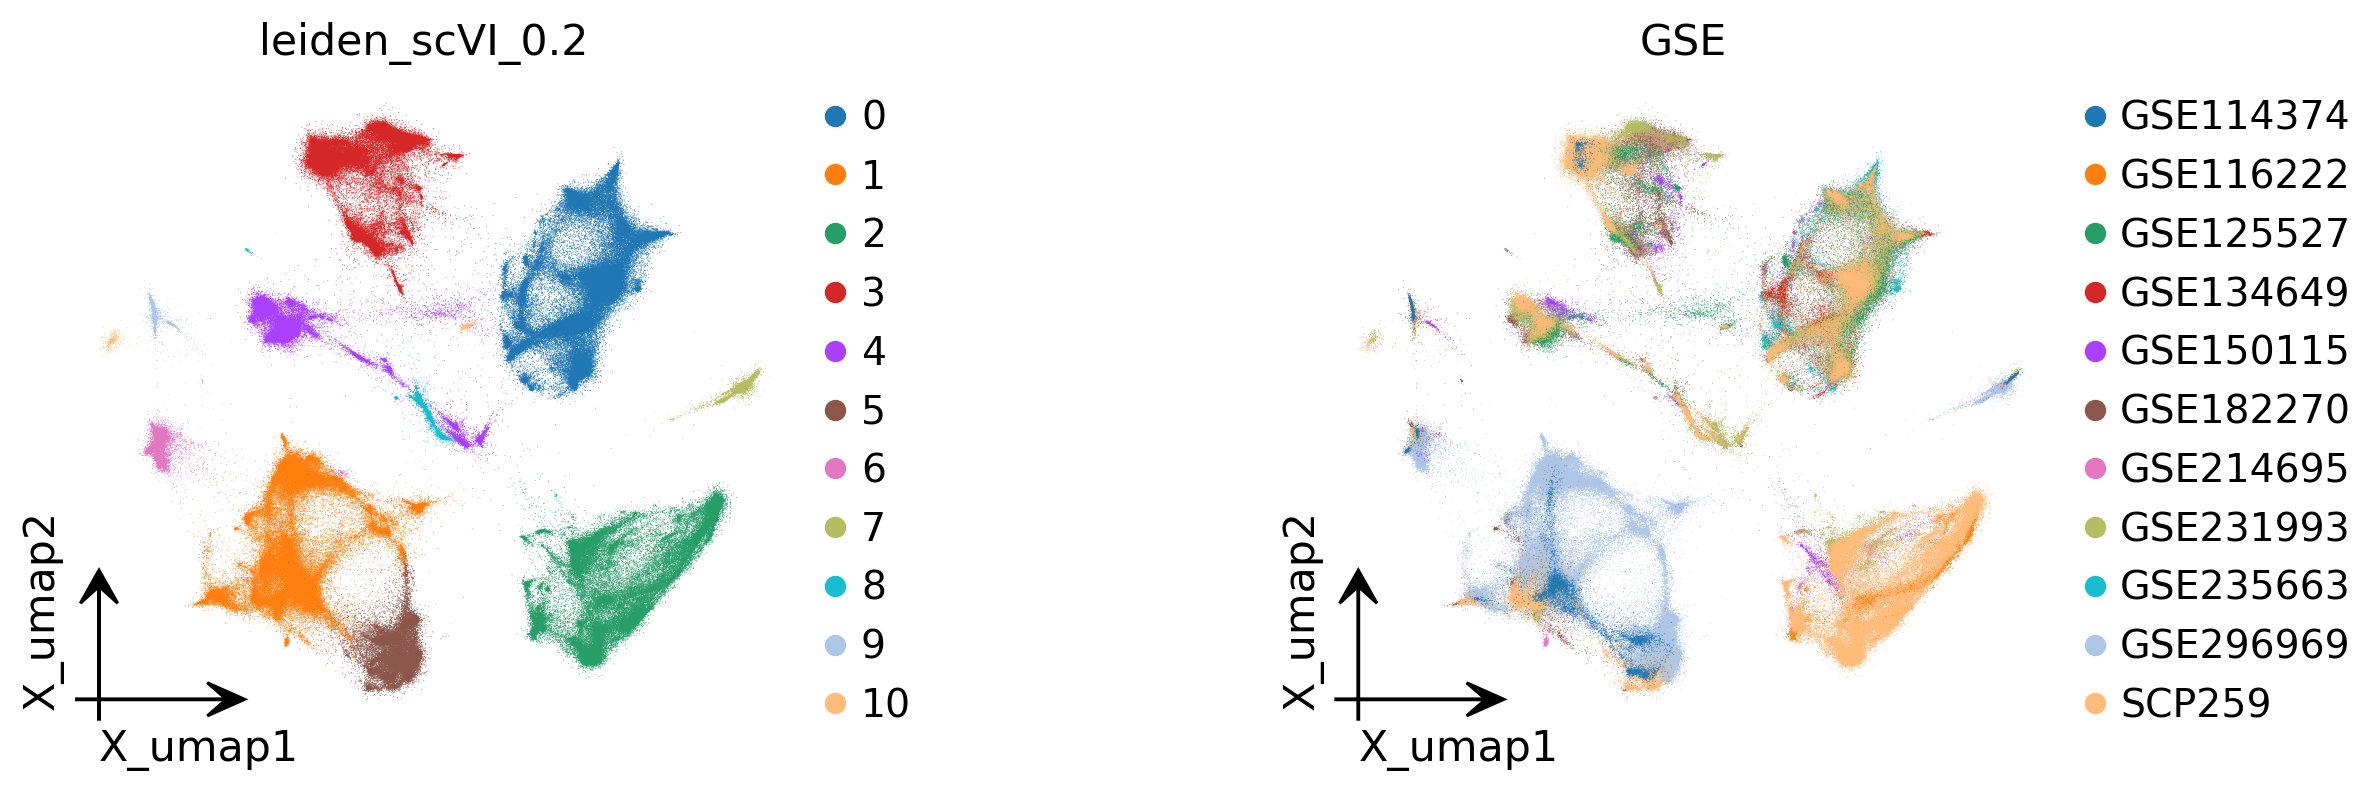

In [32]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden_scVI_0.2', 'GSE'],
                frameon='small',
                wspace=0.5)   

## 5.保存

In [33]:
adata.write_h5ad(OUT_PATH, compression="gzip")
print(f"✅ 已保存：{OUT_PATH}")

✅ 已保存：/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/05_scvi_integrated/tissue_dataset_scvi.h5ad


## GPT自动注释

In [34]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden_scVI_0.2',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:56)


{'0': ['CD2',
  'CD3E',
  'IL32',
  'ACTB',
  'CD3D',
  'SRGN',
  'PTPRC',
  'ARHGDIB',
  'CD52',
  'CD7'],
 '1': ['CFD',
  'DCN',
  'A2M',
  'COL3A1',
  'CFH',
  'COL1A2',
  'C1R',
  'COL1A1',
  'C1S',
  'FBLN1'],
 '10': ['ALOX5AP',
  'NFKBIA',
  'VWA5A',
  'SRGN',
  'TYROBP',
  'FCER1G',
  'ANXA1',
  'CAPG',
  'S100A4',
  'CD69'],
 '2': ['CLDN7',
  'KRT19',
  'KRT8',
  'KRT18',
  'EPCAM',
  'LGALS4',
  'PHGR1',
  'LGALS3',
  'PIGR',
  'C15orf48'],
 '3': ['SSR4',
  'IGKC',
  'DERL3',
  'IGHA1',
  'IGHA2',
  'MZB1',
  'XBP1',
  'HERPUD1',
  'SEC11C',
  'FKBP11'],
 '4': ['CD74',
  'LAPTM5',
  'CD83',
  'HLA-DRA',
  'CXCR4',
  'CD52',
  'CD79A',
  'CD37',
  'MS4A1',
  'RPL39'],
 '5': ['PLAT',
  'LAMA4',
  'COL6A1',
  'COL3A1',
  'COL1A1',
  'CALD1',
  'COL1A2',
  'FRZB',
  'F3',
  'COL6A2'],
 '6': ['PDGFRB',
  'COL4A1',
  'IGFBP7',
  'C11orf96',
  'MYL9',
  'CALD1',
  'ADAMTS1',
  'NR2F2',
  'NOTCH3',
  'RGS5'],
 '7': ['MATN2',
  'GPM6B',
  'PRNP',
  'CLU',
  'CD9',
  'SPARC',
  'CRYAB',

In [35]:
import os
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon tissue',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'Fibroblast',
 '10': 'Myeloid cell',
 '2': 'Epithelial cell',
 '3': 'Plasma cell',
 '4': 'B cell',
 '5': 'Fibroblast',
 '6': 'Pericyte',
 '7': 'Schwann cell',
 '8': 'Dendritic cell',
 '9': 'Endothelial cell'}

In [36]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden_scVI_0.2'].map(result).astype('category')

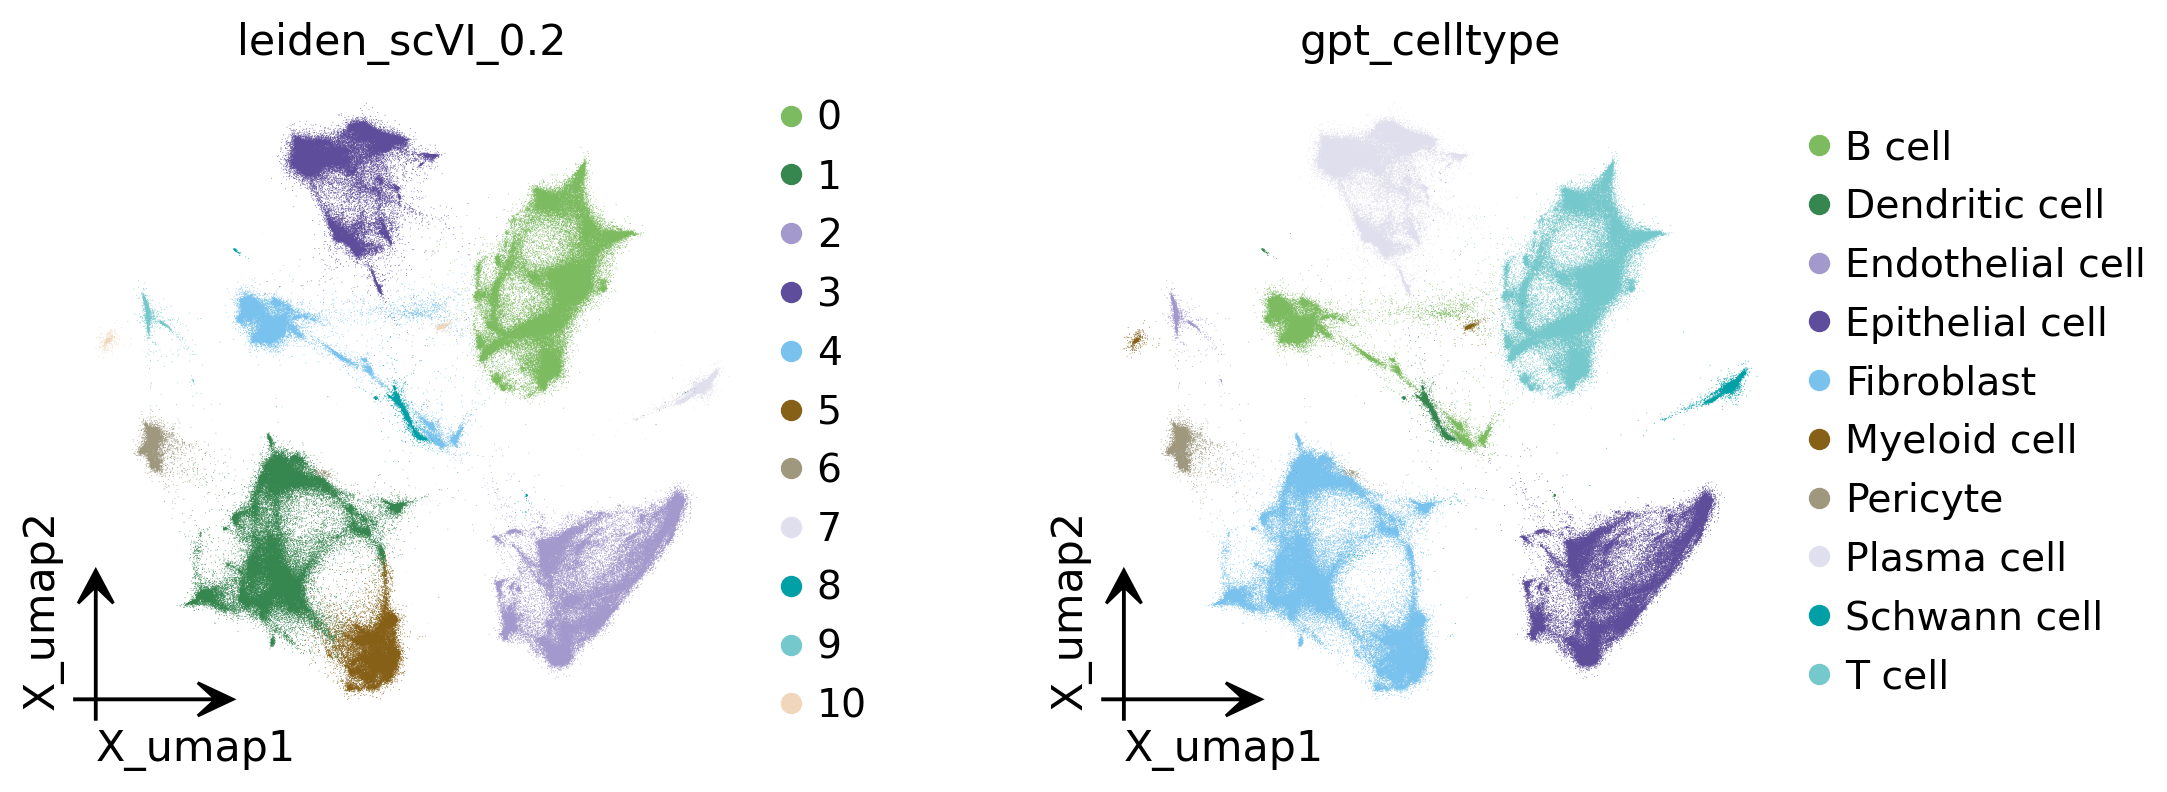

In [37]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden_scVI_0.2', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [38]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Fibroblast          26.557314
T cell              23.454034
Epithelial cell     17.317433
Plasma cell         15.734819
B cell               8.025751
Pericyte             2.706491
Schwann cell         2.051497
Dendritic cell       1.934009
Endothelial cell     1.337492
Myeloid cell         0.881158
Name: proportion, dtype: float64
